In [1]:
import sys 
sys.path.append('src')
from sr_model import *

import os
from datasets import load_from_disk, concatenate_datasets
from datasets import Dataset
import numpy as np 
import pandas as pd 
from torch.utils.data import DataLoader 

In [2]:
data_path = '../sr_project/eval_data/merge_dataset/mdata.h5mu'
import muon as mu 
mdata = mu.read_h5mu(data_path)

train_idx = np.load('../sr_project/eval_data/data_split/train_id_3.npy')
test_idx = np.load('../sr_project/eval_data/data_split/test_id_3.npy')
print(len(train_idx), len(test_idx))

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:931: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  warnings.warn(


70997 7889


/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [3]:
train_obs = mdata['rna_count'].obs.index[train_idx]
test_obs = mdata['rna_count'].obs.index[test_idx]
print(len(train_obs),len(test_obs), mdata.shape)

70997 7889 (78886, 696445)


## 10x multi 数据预处理

In [4]:
# idx = mdata.obs.loc[:,'rna_count:tissues'] != '10x_multi'
rna = mdata['rna_count']
# rna = rna[idx,:]
atac = mdata['peak_count']
# atac = atac[idx,:]

mdata = MuData({'rna_count': rna, 'peak_count': atac})

/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1531: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rsun@ZHANGroup.local/anaconda3/envs/snapatac/lib/python3.10/site-packages/mudata/_core/mudata.py:1429: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [5]:
import scanpy as sc 
print(rna.shape)
sc.pp.filter_genes(rna, min_cells = int(rna.shape[0] * 0.01))
print(rna.shape) 

sc.pp.normalize_total(rna, target_sum = 1e4)
sc.pp.log1p(rna) 


print(atac.shape)
sc.pp.filter_genes(atac, min_cells = int(atac.shape[0] * 0.01))
print(atac.shape)

sc.pp.normalize_total(atac, target_sum =1e4 )
sc.pp.log1p(atac)

(78886, 32285)
(78886, 14378)
(78886, 608869)
(78886, 141343)


In [6]:
# train_rna = rna[train_idx,:]
# test_rna = rna[test_idx,:]

# train_atac = atac[train_idx,:]
# test_atac = atac[test_idx,:]

# train_mdata = MuData({'rna': train_rna, 'atac': train_atac})
# test_mdata = MuData({'rna': test_rna, 'atac': test_atac})

## 设置pair_sr模型

In [7]:
train_pos = mdata['rna_count'].obs.index.get_indexer(train_obs)
test_pos = mdata['rna_count'].obs.index.get_indexer(test_obs)

print(len(train_obs),len(test_obs))

70997 7889


In [8]:
feature_num_1 = rna.shape[1]
feature_num_2 = atac.shape[1]


hidden_params_1 = [1024,512,256]
hidden_params_2 = [1024,512,256]
embed_dim = 128
use_rmsnorm = True
use_residual = True 
dropout_p = 0
clip_temperature = 0.07


pair_model = pair_sr_scratch(feature_num_1, feature_num_2, hidden_params_1, hidden_params_2, embed_dim, use_rmsnorm, use_residual, dropout_p, clip_temperature)



In [9]:
# pair_model.set_loss(vae_beta_1= 1.0, vae_beta_2 = 1.0, clip_weight =  20, cross_recon_1 = 0.4,cross_recon_2 = 0.4,temperature = 0.07)
# pair_model.loss.clip_loss.logit_scale

In [10]:
pair_model.create_dataset(mdata, 'rna_count', 'peak_count', train_idx = train_pos, test_idx = test_pos)
pair_model.set_dataloader(batch_size = 512)

In [11]:
# pair_model.set_dataloader(batch_size = 1024)
pair_model.set_loss(vae_beta_1= 1.0, vae_beta_2 = 1.0, clip_weight =  40, cross_recon_1 = 0.4,cross_recon_2 = 0.4,temperature = 0.07)
#pair_model.loss.to('cuda')
# pair_model.set_optimizer(lr = 1e-3, warmup_steps=1000, steady_1_steps = 1600, cosine_anneal_steps=6000, min_lr = 1e-4)
# pair_model.set_project('runs/clip_case_')
# pair_model.train_model( train_steps = 10000 ,eval_points = 80,save_points = 1000,device = 'cuda')

In [17]:
for key in range(10,11):
    print('==========='*10)
    key = int(1000*key)    
    pair_model.init_model(f'/home/rsun@ZHANGroup.local/solid-recover/runs/clip_case_3/models/ckpt_{key}.pth')

    model = pair_model.model 
    model.to('cpu')
    model.eval()

    x1 = pair_model.test_dataset.omic_1.to('cpu')
    x2 = pair_model.test_dataset.omic_2.to('cpu')

    z, z_mu, z_logvar, z_embed = model.model_1.get_embedding(x1)
    y,y_mu, y_logvar, y_embed  = model.model_2.get_embedding(x2)

    import anndata as ad 

    N = z_embed.shape[0]

    z_mu = z_mu.detach().cpu().numpy()
    z_embed = z_embed.detach().cpu().numpy()

    y_mu = y_mu.detach().cpu().numpy()
    y_embed = y_embed.detach().cpu().numpy()

    mu = np.concatenate([z_mu, y_mu], axis = 0)
    print(mu.shape)
    embed = np.concatenate([z_embed, y_embed], axis = 0)
    print(embed.shape)

    import numpy as np 
    import pandas as pd 
    import json
    import scanpy as sc

    import matplotlib.pyplot as plt 
    import seaborn as sns 
    import os 
    import sys
    import anndata as ad

    sys.path.append('/home/rsun@ZHANGroup.local/sr_project/src')
    from metrics import calculate_hit_rate, matching_metrics


    ## perform evaluation
    res = {}
    ### calculate top_k hit rate
    tmp = []
    for i in [1,5,10,15,20,30,50,100]:
        res[f'top_{i}_hit'] = calculate_hit_rate(z_mu, y_mu, i, metric = 'euclidean')
    print(res)

    ### calculate metric score
    acc, ms, fs = matching_metrics(x=z_embed, y = y_embed, metric='euclidean')
    res['acc'] = acc 
    res['mathscore'] = ms 
    res['foscttm'] = fs

    print(res)


    ## perform evaluation
    res = {}
    ### calculate top_k hit rate
    tmp = []
    for i in [1,5,10,15,20,30,50,100]:
        res[f'top_{i}_hit'] = calculate_hit_rate(z_mu, y_mu, i, metric = 'cosine')
    print(res)

    ### calculate metric score
    acc, ms, fs = matching_metrics(x=z_embed, y = y_embed, metric='cosine')
    res['acc'] = acc 
    res['mathscore'] = ms 
    res['foscttm'] = fs

    print(res)



/home/rsun@ZHANGroup.local/solid-recover/src/sr_model.py:133: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


(15778, 128)
(15778, 128)
{'top_1_hit': 0.12694891621244772, 'top_5_hit': 0.2932564330079858, 'top_10_hit': 0.3854734440359995, 'top_15_hit': 0.4426416529344657, 'top_20_hit': 0.4813664596273292, 'top_30_hit': 0.5360628723539105, 'top_50_hit': 0.604829509443529, 'top_100_hit': 0.6983141082519965}
{'top_1_hit': 0.12694891621244772, 'top_5_hit': 0.2932564330079858, 'top_10_hit': 0.3854734440359995, 'top_15_hit': 0.4426416529344657, 'top_20_hit': 0.4813664596273292, 'top_30_hit': 0.5360628723539105, 'top_50_hit': 0.604829509443529, 'top_100_hit': 0.6983141082519965, 'acc': 0.1008366048336029, 'mathscore': 0.10495626926422119, 'foscttm': 0.030830212868750095}
{'top_1_hit': 0.12821650399290152, 'top_5_hit': 0.2933198123970085, 'top_10_hit': 0.3889593104322474, 'top_15_hit': 0.44492331093928256, 'top_20_hit': 0.48269742679680566, 'top_30_hit': 0.5404994295854988, 'top_50_hit': 0.6081886170617316, 'top_100_hit': 0.7000887311446318}
{'top_1_hit': 0.12821650399290152, 'top_5_hit': 0.29331981239

In [ ]:
#0.1047
#0.109 
# 0.1266 
# 0.1319
# 0.1385
# 0.1379


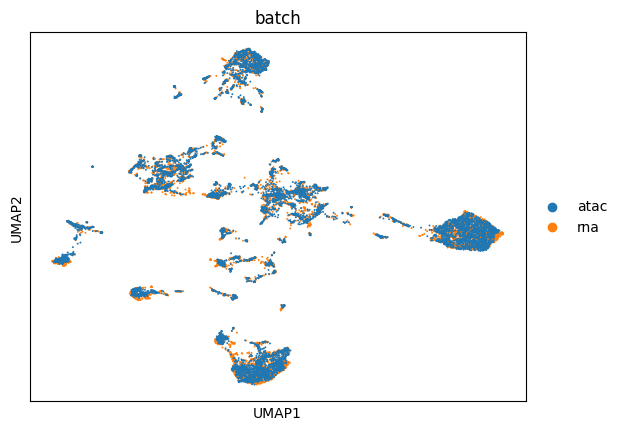

In [13]:
adata = ad.AnnData(X = np.random.rand(2*N,10))
adata.obs.loc[:,'batch'] = ['rna']*N + ['atac']*N
adata.obsm['mu'] = mu 
adata.obsm['embed'] = mu 

sc.pp.neighbors(adata, use_rep='mu')
sc.tl.umap(adata, min_dist = 0.1)
sc.pl.umap(adata, color='batch')



In [ ]:
sc.pp.neighbors(adata, use_rep='embed')
sc.tl.umap(adata, min_dist = 0.1)
sc.pl.umap(adata, color='batch')
